# Verify polytope functions: C++ (Microstructure/Sample_Pn_UU) vs. pure Python (calculate_polytopes_python)

Runs both implementations on the same 2D binary image and plots the resulting `p3h`, `p3v`, `p4`, `p6`, and `L` curves on top of each other for a visual sanity check, alongside the numeric max-diff table.

**Requirements to run the C++ side:**
- `cpp_poly/512/Cpp_source/Polytope/Sample_Pn_UU` must be a working, statically-linked build (see `compare_polytopes.py` at the repo root for background - the original dynamically-linked build needs MinGW runtime DLLs that may not be on PATH).
- Run this notebook with a kernel from the `gui_micro` conda env (needs `numpy`, `numba`, `pandas`, `matplotlib`, `tifffile`; install `ipykernel` in that env if it doesn't show up as a kernel choice: `pip install ipykernel` then select the env's interpreter in VS Code / `python -m ipykernel install --user --name gui_micro`).

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `from src.micro_gui...` resolves the same way calculate_SMD.py does

import numpy as np
import matplotlib.pyplot as plt
import tifffile

from src.micro_gui.analysis.smds import calculate_polytopes, calculate_polytopes_python

## Load the test image

Image shape: (512, 512), foreground (pore) fraction: 0.2504


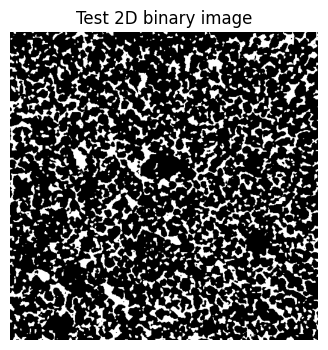

In [2]:
IMAGE_PATH = "../test_images/XCT_11.4um_binary0000.tif"

img = tifffile.imread(IMAGE_PATH).astype(np.uint8)
print(f"Image shape: {img.shape}, foreground (pore) fraction: {img.mean():.4f}")

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("Test 2D binary image")
plt.axis("off")
plt.show()

## Run the old C++-based method (`calculate_polytopes`)

This is the same function `calculate_SMD.py` uses - it writes `Mconfig.txt`, shells out to the compiled `Sample_Pn_UU` executable, and reads back the `Sobj*.txt`/`sobj*.txt` outputs.

In [3]:
POLYTOPES = ["p3h", "p3v", "p4", "p6", "L"]

par = {"name": "polytopes", "begx": 0, "begy": 0, "nsamp": img.shape[0], "edge_buffer": 0}

cpathPn = "../cpp_poly/512/Cpp_source/Polytope/"
runtimePn = "../cpp_poly/512/runtime/"
outputPn = "../cpp_poly/512/runtime/output/"

In [4]:
cpp_raw = {}
cpp_scaled = {}

for name in POLYTOPES:
    try:
        raw, scaled = calculate_polytopes(img, par, outputPn, cpathPn, runtimePn, polytope=name)
        cpp_raw[name] = raw
        cpp_scaled[name] = scaled
        print(f"{name}: cpp done")
    except Exception as e:
        print(f"{name}: CPP FAILED - {type(e).__name__}: {e}")

p3h: cpp done
p3v: cpp done
p4: cpp done
p6: cpp done
L: cpp done


## Run the new pure-Python/numba method (`calculate_polytopes_python`)

One call computes everything requested directly on the numpy array - no Mconfig.txt, no subprocess, no compiled executable.

In [5]:
py_raw, py_scaled = calculate_polytopes_python(img, polytopes=tuple(POLYTOPES))
print("python done:", list(py_raw.keys()))

python done: ['p3h', 'p3v', 'p4', 'p6', 'L']


## Numeric comparison table (raw Pn(r) curves)

In [6]:
print(f"{'polytope':10s} {'max_abs_diff':>14s} {'max_rel_diff':>14s} {'n_mismatch(>1e-4)':>20s}")
for name in POLYTOPES:
    if name not in cpp_raw:
        print(f"{name:10s}  (skipped - cpp run failed above)")
        continue
    ref = cpp_raw[name][:, 1]
    mine = py_raw[name][:, 1]
    diff = np.abs(mine - ref)
    rel = diff / np.maximum(np.abs(ref), 1e-12)
    n_mismatch = int(np.sum(diff > 1e-4))
    print(f"{name:10s} {diff.max():14.8f} {rel.max():14.8f} {n_mismatch:20d}")

polytope     max_abs_diff   max_rel_diff    n_mismatch(>1e-4)
p3h            0.00007551     0.00396041                    0
p3v            0.00009094     0.00581134                    0
p4             0.00005696     0.00785702                    0
p6             0.00003043     0.03342919                    0
L              0.00000050     0.05004009                    0


## Plot: raw Pn(r) curves, C++ vs. Python overlaid

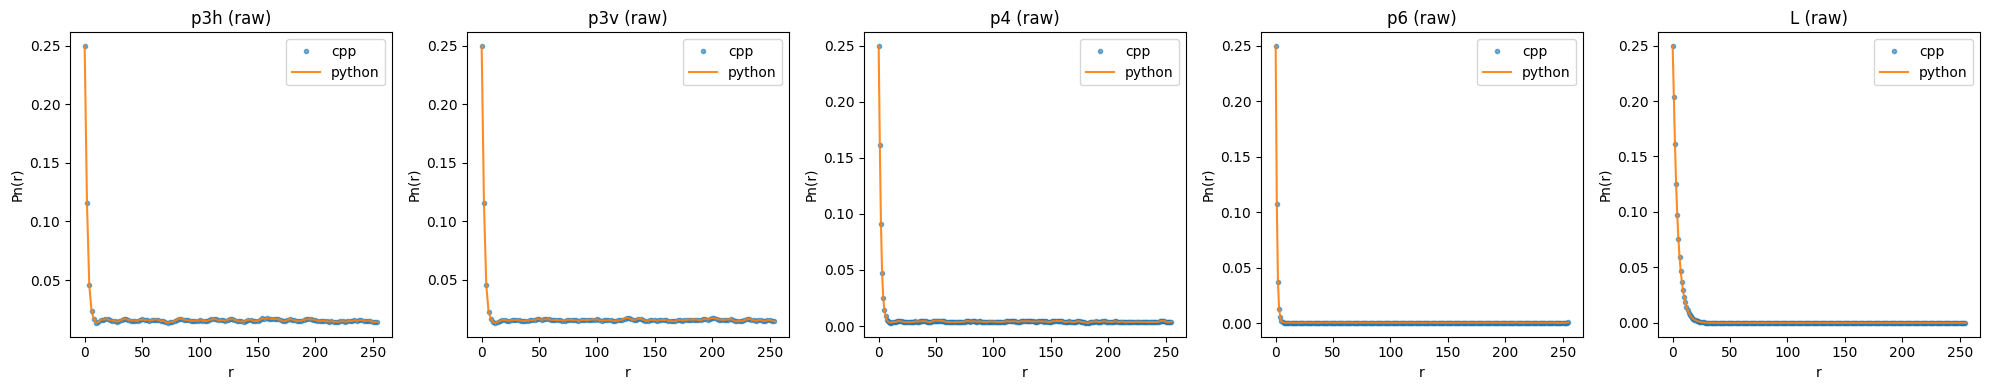

In [10]:
fig, axes = plt.subplots(1, len(POLYTOPES), figsize=(4 * len(POLYTOPES), 4), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, POLYTOPES):
    if name in cpp_raw:
        if name in ["p3h", "p3v"]:
            ax.plot(cpp_raw[name][::2, 0], cpp_raw[name][::2, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_raw[name][::2, 0], py_raw[name][::2, 1], "-", lw=1.5, alpha=0.9, label="python")
        else:
            ax.plot(cpp_raw[name][:, 0], cpp_raw[name][:, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_raw[name][:, 0], py_raw[name][:, 1], "-", lw=1.5, alpha=0.9, label="python")
    ax.set_title(f"{name} (raw)")
    ax.set_xlabel("r")
    ax.set_ylabel("Pn(r)")
    ax.legend()

plt.tight_layout()
plt.show()

## Plot: scaled fn(r) curves, C++ vs. Python overlaid

(`fn` is the normalised companion curve - `polyfn_*` for P3H/P3V/P4/P6, and the S2-based `scal_autocov` for `L`, matching the original `Microstructure` class.)

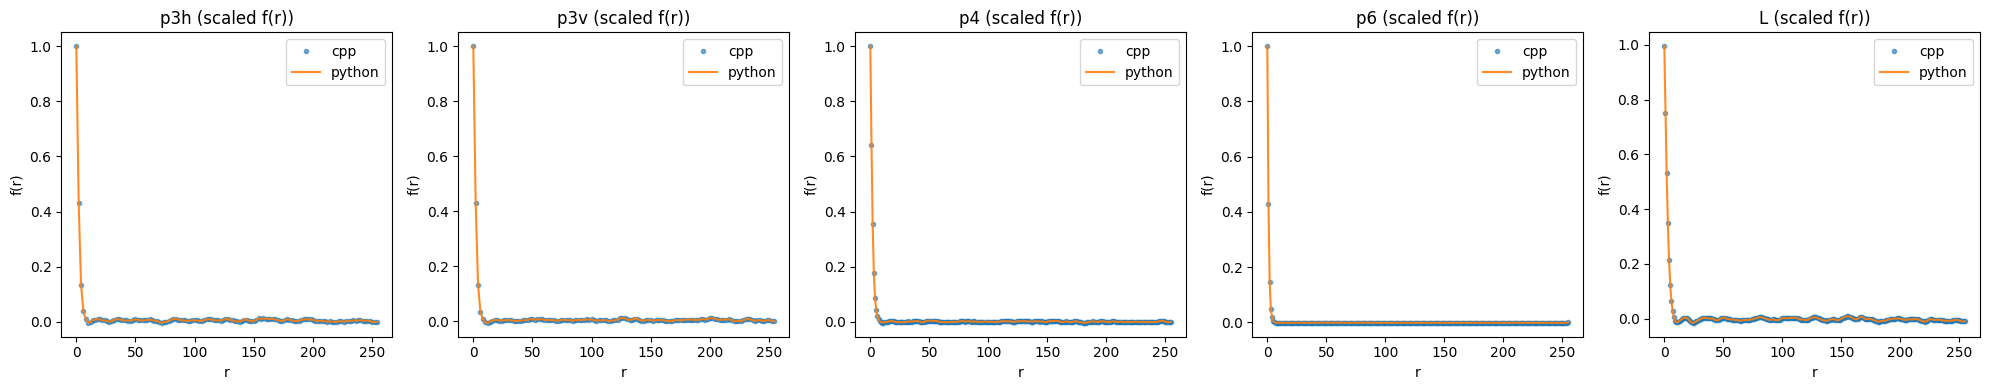

In [13]:
fig, axes = plt.subplots(1, len(POLYTOPES), figsize=(4 * len(POLYTOPES), 4), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, POLYTOPES):
    if name in cpp_scaled:
        if name in ["p3h", "p3v"]:
            ax.plot(cpp_scaled[name][::2, 0], cpp_scaled[name][::2, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_scaled[name][::2, 0], py_scaled[name][::2, 1], "-", lw=1.5, alpha=0.9, label="python")
        else:
            ax.plot(cpp_scaled[name][:, 0], cpp_scaled[name][:, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_scaled[name][:, 0], py_scaled[name][:, 1], "-", lw=1.5, alpha=0.9, label="python")
    ax.set_title(f"{name} (scaled f(r))")
    ax.set_xlabel("r")
    ax.set_ylabel("f(r)")
    ax.legend()

plt.tight_layout()
plt.show()

## Plot: difference (python - cpp) vs. r, raw curves

A closer look at how small the disagreement actually is (should hover near zero everywhere).

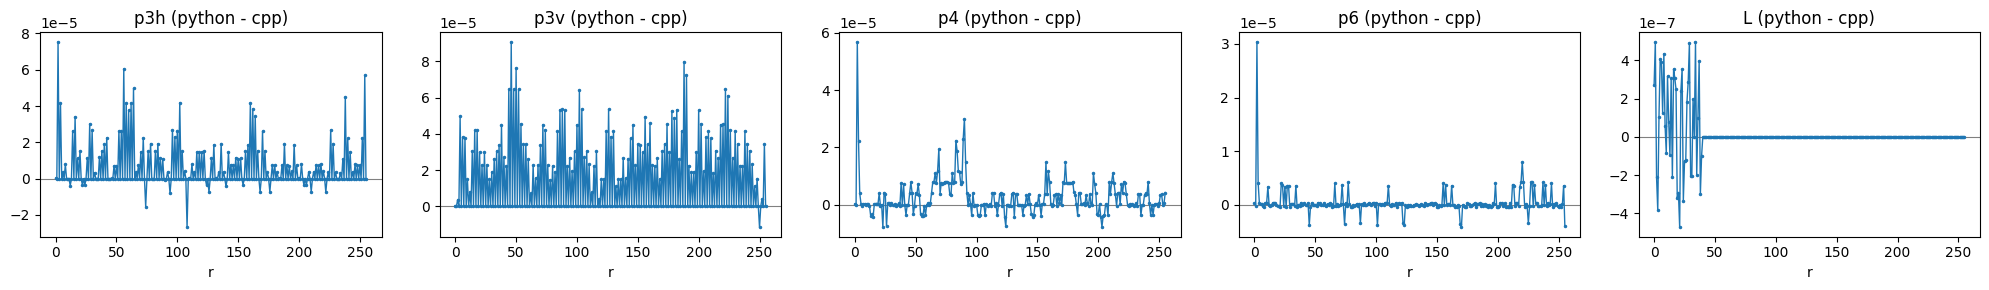

In [14]:
fig, axes = plt.subplots(1, len(POLYTOPES), figsize=(4 * len(POLYTOPES), 3), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, POLYTOPES):
    if name not in cpp_raw:
        continue
    r = py_raw[name][:, 0]
    diff = py_raw[name][:, 1] - cpp_raw[name][:, 1]
    ax.axhline(0, color="gray", lw=0.8)
    ax.plot(r, diff, ".-", ms=3, lw=1)
    ax.set_title(f"{name} (python - cpp)")
    ax.set_xlabel("r")

plt.tight_layout()
plt.show()